In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

%matplotlib inline

In [3]:
df = pd.read_csv("C:/Users/chitn/OneDrive/Desktop/y3 lets gooo/Chapter 2/DM/HybridDataset.csv")

In [7]:
print(df.isnull().sum())

Unnamed: 0                                                                                             0
what is your age group?                                                                                0
what is your occupation?                                                                               0
how many hours per day do you spend online?                                                            0
what device do you use most to access the internet?                                                    0
what is the total number of social media platforms that you use?                                       0
which social media platforms do you use regularly?                                                     0
what is your most used social media platform?                                                          0
could you spend an entire week without social media?                                                   0
the first thing you do after walking up is scroll throu

In [8]:
selected_columns = [
    'what is your age group?', 
    'how many hours per day do you spend online?',
    'which social media platforms do you use regularly?',
    'what do you primarily use the internet for?',
    'which activities do you engage in most on social media?',
    'how often do you find yourself distracted while working or studying due to social media?',
    'what types of notifications or distractions affect you the most?',
    'do you feel like attention is being monetized by platforms?',
    'category'  # นี่คือ Target
]

df_selected = df[selected_columns].copy()

In [9]:
column_mapping = {
    'what is your age group?': 'age_group',
    'how many hours per day do you spend online?': 'hours_online',
    'which social media platforms do you use regularly?': 'regular_platforms',
    'what do you primarily use the internet for?': 'primary_use',
    'which activities do you engage in most on social media?': 'sm_activities',
    'how often do you find yourself distracted while working or studying due to social media?': 'distraction_freq',
    'what types of notifications or distractions affect you the most?': 'distraction_types',
    'do you feel like attention is being monetized by platforms?': 'monetization_awareness',
    'category': 'target'
}

df_selected = df_selected.rename(columns=column_mapping)

In [10]:
print(df_selected.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   age_group               310 non-null    object
 1   hours_online            310 non-null    object
 2   regular_platforms       310 non-null    object
 3   primary_use             310 non-null    object
 4   sm_activities           310 non-null    object
 5   distraction_freq        310 non-null    object
 6   distraction_types       310 non-null    object
 7   monetization_awareness  310 non-null    object
 8   target                  310 non-null    object
dtypes: object(9)
memory usage: 21.9+ KB
None


In [12]:
df_selected.head()

,age_group,hours_online,regular_platforms,primary_use,sm_activities,distraction_freq,distraction_types,monetization_awareness,target
0,18-24,Less than 2,"Snapchat, Twitch, Spotify","Social Media, News","Shopping, Liking, Sharing and Commenting",Sometimes,"Social Media notifications, Suggested videos o...",No,Moderately Aware
1,18-24,Less than 2,"Facebook, Instagram, X, Spotify","News, Social Media, Gaming","Liking, Sharing and Commenting, Watching Video...",Sometimes,"Ads and Pop-ups, Messages (Text, Emails, Chats)",Yes,Highly Aware
2,18-24,"""6-8""","Facebook, Reddit, X, YouTube","Studying/Work, News","Watching Videos, Shopping, Posting Content",Rarely,"Social Media notifications, Messages (Text, Em...",Yes,Moderately Aware
3,35-44,Less than 2,"Snapchat, YouTube","Gaming, News, Shopping","Posting Content, Shopping, Watching Videos",Often,"Ads and Pop-ups, Messages (Text, Emails, Chats)",No,Moderately Aware
4,25-34,"""2-4""","X, Pinterest","Entertainment, Social Media, Gaming","Watching Videos, Shopping, Posting Content",Rarely,"Social Media notifications, Trending posts or ...",Yes,Highly Aware


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [14]:
# จัดการข้อมูลรายการ (Count Features)
list_cols = ['regular_platforms', 'primary_use', 'sm_activities', 'distraction_types']
for col in list_cols:
    df_selected[f'{col}_count'] = df_selected[col].apply(lambda x: len(str(x).split(',')))

# ลบคอลัมน์ข้อความเดิมและทำ Encoding
df_final = df_selected.drop(columns=list_cols)
le = LabelEncoder()
for col in df_final.select_dtypes(include=['object']).columns:
    df_final[col] = le.fit_transform(df_final[col].astype(str))

# สร้างและทดสอบโมเดล
X = df_final.drop('target', axis=1)
y = df_final['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# ดูผลความแม่นยำ
print(f"Accuracy: {model.score(X_test, y_test)*100:.2f}%")

Accuracy: 100.00%



Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        29
           2       1.00      1.00      1.00        14

    accuracy                           1.00        62
   macro avg       1.00      1.00      1.00        62
weighted avg       1.00      1.00      1.00        62



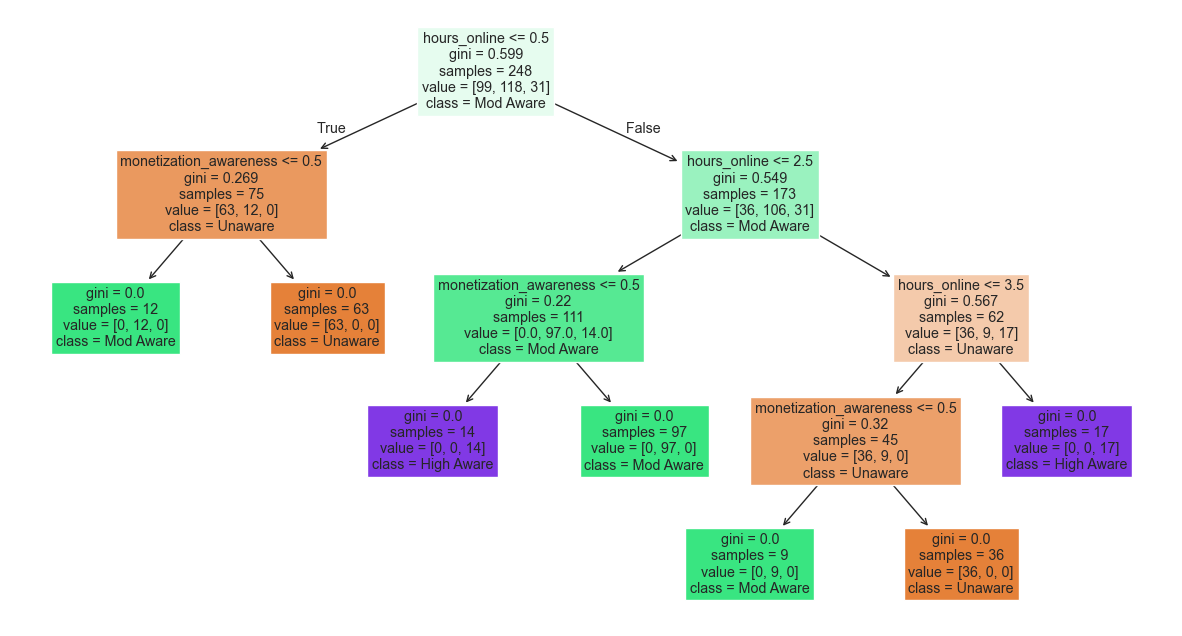

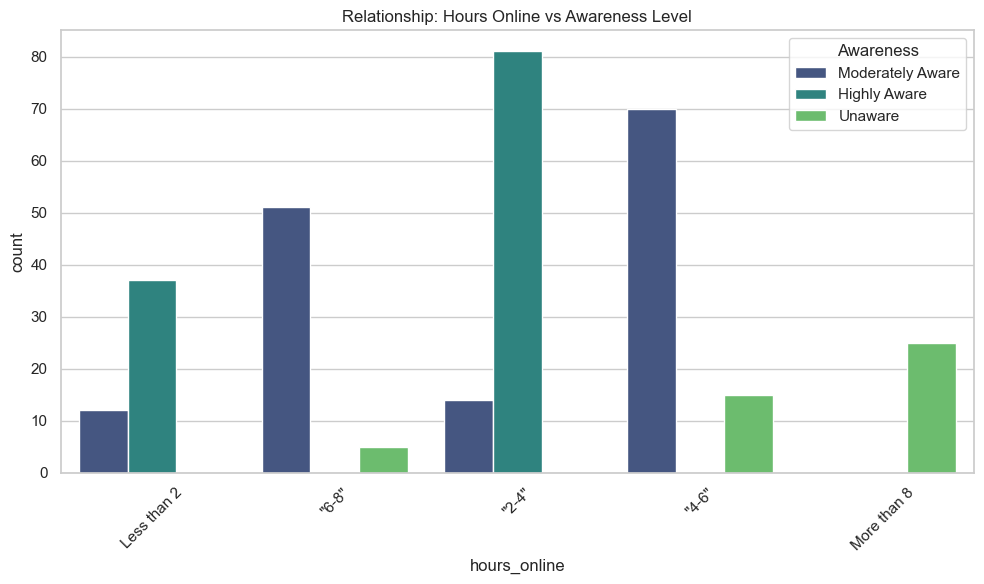

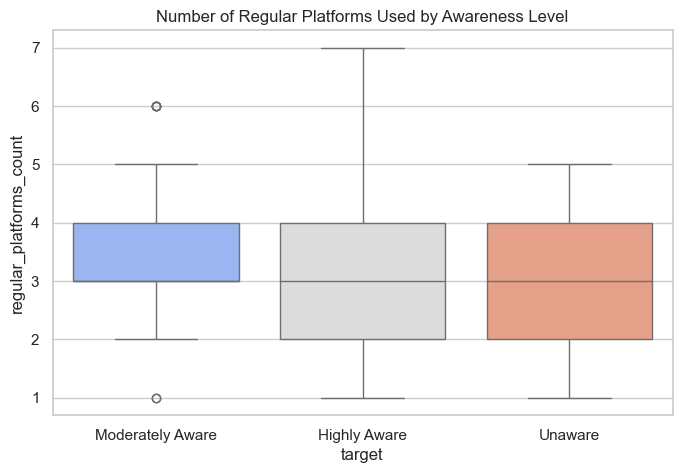

In [27]:
print("\nClassification Report:\n", classification_report(y_test, y_pred=model.predict(X_test)))
sns.set(style="whitegrid")

# แสดงกราฟต้นไม่การตัดสินใจ
plt.figure(figsize=(15,8))
plot_tree(model, feature_names=X.columns, class_names=['Unaware', 'Mod Aware', 'High Aware'], filled=True)
plt.show()

# ความสัมพันธ์ระหว่าง ชั่วโมงออนไลน์ กับ ระดับความตระหนักรู้
plt.figure(figsize=(10, 6))
# ใช้ df_selected เพื่อให้กราฟแสดงเป็นชื่อข้อความ (ยังไม่ถูก encode เป็นตัวเลข)
sns.countplot(data=df_selected, x='hours_online', hue='target', palette='viridis')
plt.title('Relationship: Hours Online vs Awareness Level')
plt.xticks(rotation=45)
plt.legend(title='Awareness')
plt.tight_layout()
plt.show()

# วิเคราะห์จำนวนแพลตฟอร์มที่ใช้ (Count Features) เทียบกับ Target
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_selected, x='target', y='regular_platforms_count', hue='target', palette='coolwarm', legend=False)
plt.title('Number of Regular Platforms Used by Awareness Level')
plt.show()